In [4]:
# Exploratory Data Analysis on a Dataset

# 1. Data Cleaning and Preparation
# Importing Libraries and loading dataset into DataFrame.


#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#loading dataset
data = pd.read_csv('Cardiotocographic.csv')
data

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,73.0,0.5,43.000000,2.4,64.0,0.999926,2.000000
1,132.000000,0.006380,0.000000,0.006380,0.003190,0.0,0.0,17.0,2.1,0.000000,10.4,130.0,0.000000,1.000000
2,133.000000,0.003322,0.000000,0.008306,0.003322,0.0,0.0,16.0,2.1,0.000000,13.4,130.0,0.000000,1.000000
3,134.000000,0.002561,0.000000,0.007742,0.002561,0.0,0.0,16.0,2.4,0.000000,23.0,117.0,1.000000,1.000000
4,131.948232,0.006515,0.000000,0.008143,0.000000,0.0,0.0,16.0,2.4,0.000000,19.9,117.0,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.000000,0.000000,0.961268,0.007426,0.000000,0.0,0.0,79.0,0.2,25.000000,7.2,40.0,0.000000,2.000000
2122,140.000000,0.000775,0.000000,0.006979,0.000000,0.0,0.0,78.0,0.4,22.000000,7.1,66.0,1.000000,2.000000
2123,140.000000,0.000980,0.000000,0.006863,0.000000,0.0,0.0,79.0,0.4,20.000000,6.1,67.0,1.000000,1.990464
2124,140.000000,0.000679,0.000000,0.006110,0.000000,0.0,0.0,78.0,0.4,27.000000,7.0,66.0,1.000000,2.000000


In [15]:
#Checking missing values
missing_values = data.isnull().sum()      # Calculate the sum of missing values for each column in the dataset
print(missing_values)

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64


In [16]:
#Data Conversion - This code attempts to convert all data to numeric but preserves the original values for any columns that contain non-numeric data.
data = data.apply(pd.to_numeric, errors='ignore')        #convert non-numeric data to numeric data. If the value cannot be converted, it is ignored.
data.head()

<ipython-input-16-fd70fdc4870b>:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(pd.to_numeric, errors='ignore')        #convert non-numeric data to numeric data. If the value cannot be converted, it is ignored.


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [17]:
#Detect and treat outliers
from scipy.stats import zscore
z_scores = np.abs(zscore(data.select_dtypes(include=[np.number])))      # Calculate absolute z-scores for all numeric columns in the dataset
outliers = (z_scores > 3).any(axis=1)                                   # Create boolean mask for rows where any column has z-score > 3 (outliers)
data = data[~outliers]                                                  # Remove outlier rows from the dataset using the boolean mask
data

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,73.0,0.5,43.000000,2.4,64.0,0.999926,2.000000
1,132.000000,0.006380,0.000000,0.006380,0.003190,0.0,0.0,17.0,2.1,0.000000,10.4,130.0,0.000000,1.000000
2,133.000000,0.003322,0.000000,0.008306,0.003322,0.0,0.0,16.0,2.1,0.000000,13.4,130.0,0.000000,1.000000
3,134.000000,0.002561,0.000000,0.007742,0.002561,0.0,0.0,16.0,2.4,0.000000,23.0,117.0,1.000000,1.000000
4,131.948232,0.006515,0.000000,0.008143,0.000000,0.0,0.0,16.0,2.4,0.000000,19.9,117.0,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2120,140.000000,0.000000,0.000000,0.004975,0.001244,0.0,0.0,77.0,0.7,17.000000,6.0,31.0,0.000000,1.000000
2122,140.000000,0.000775,0.000000,0.006979,0.000000,0.0,0.0,78.0,0.4,22.000000,7.1,66.0,1.000000,2.000000
2123,140.000000,0.000980,0.000000,0.006863,0.000000,0.0,0.0,79.0,0.4,20.000000,6.1,67.0,1.000000,1.990464
2124,140.000000,0.000679,0.000000,0.006110,0.000000,0.0,0.0,78.0,0.4,27.000000,7.0,66.0,1.000000,2.000000


In [18]:
# 2. Statistical summary

summary = data.describe()           # Generate descriptive statistics of the DataFrame 'data'
print(summary)

                LB           AC           FM           UC           DL  \
count  1954.000000  1955.000000  1974.000000  1974.000000  1974.000000   
mean    133.441667     0.003280     0.004290     0.004368     0.001752   
std      11.162659     0.004434     0.013575     0.002891     0.002728   
min      52.000000    -0.019284    -0.005106    -0.000132    -0.000124   
25%     126.000000     0.000000     0.000000     0.001975     0.000000   
50%     133.000000     0.001705     0.000000     0.004521     0.000000   
75%     141.000000     0.005820     0.002367     0.006534     0.003085   
max     214.000000     0.038567     0.189320     0.013861     0.011837   

                DS           DP         ASTV         MSTV         ALTV  \
count  1954.000000  1954.000000  1974.000000  1974.000000  1974.000000   
mean      0.000003     0.000155    46.928060     1.297879     9.143254   
std       0.000144     0.000823    16.866324     0.783910    16.678182   
min      -0.001353    -0.005348    11

In [19]:
#Highlighting findings with highest standard deviation
std_dev = data.std()                                                      # Calculate standard deviation for all variables in the dataset
max_std_dev_var = std_dev.idxmax()                                        # Find the variable name (column) with the highest standard deviation
print(f"Variable with highest standard deviation: {max_std_dev_var}")

Variable with highest standard deviation: Width


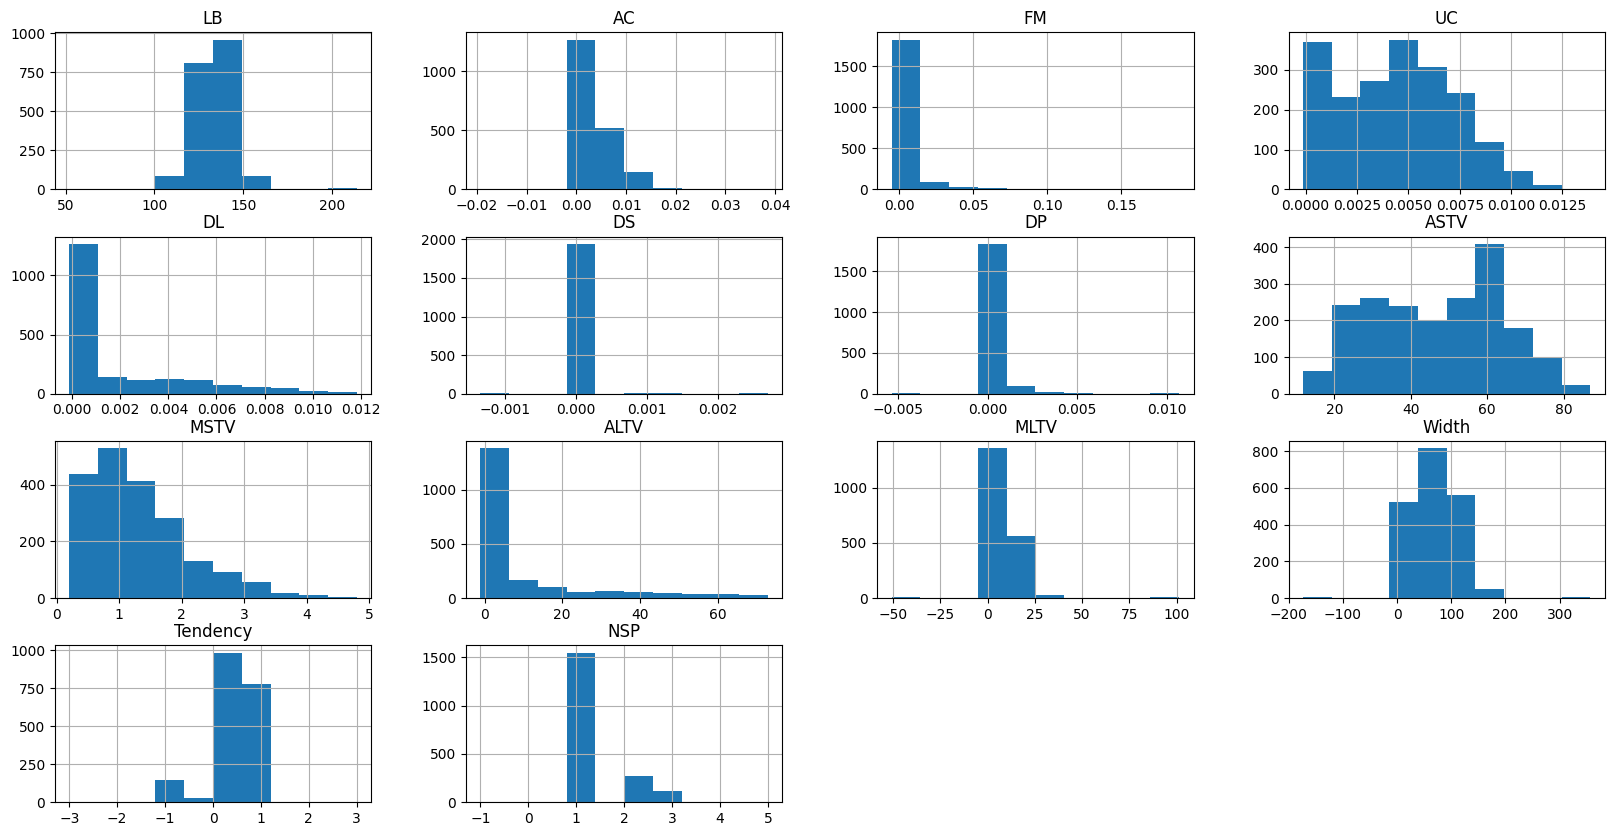

In [22]:
#3. Data Visualization

#Histogram
data.hist(figsize=(20,10))      # Create histograms for all numeric columns in the 'data' DataFrame and Set figure size to 20x10 inches for better visibility
plt.show()

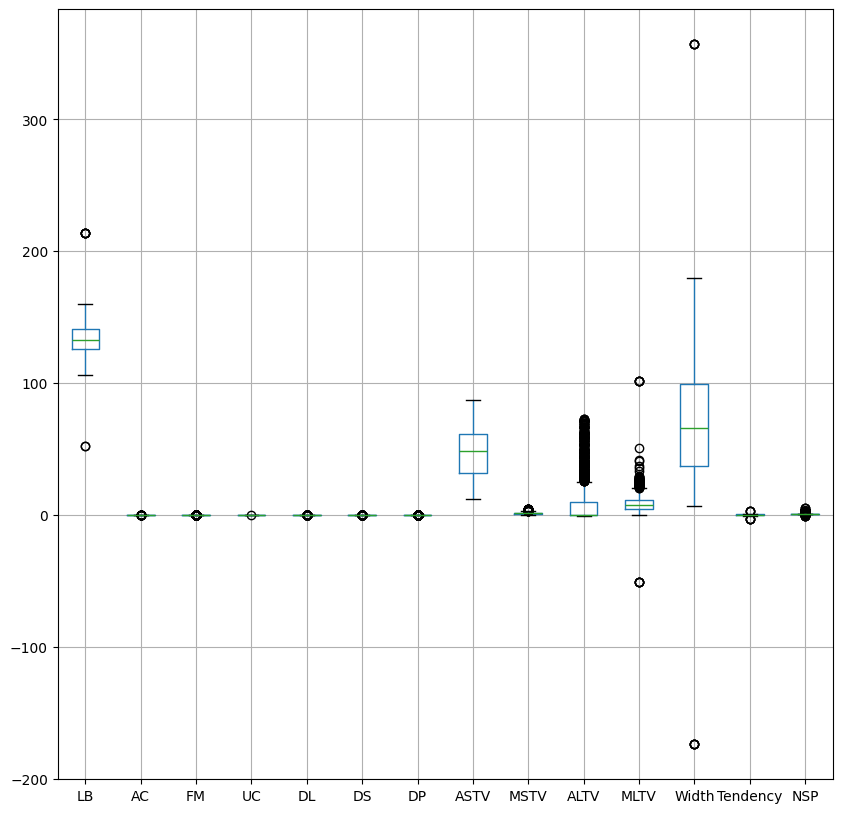

In [25]:
#box plot
data.boxplot(figsize=(10,10))      # Create a box plot to visualize the distribution of numerical variables. figsize=(10,9) sets the figure size to 10 inches width and 10 inches height
plt.show()

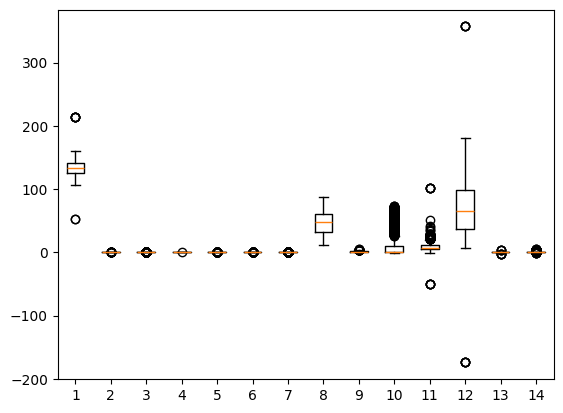

In [26]:
# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# Remove rows with missing values and store in new dataframe
data_box = data.dropna()

# Create a copy of the cleaned dataframe
data1_box = data_box
data1_box

# Create and display a box plot of the data
plt.boxplot(data1_box)
plt.show()

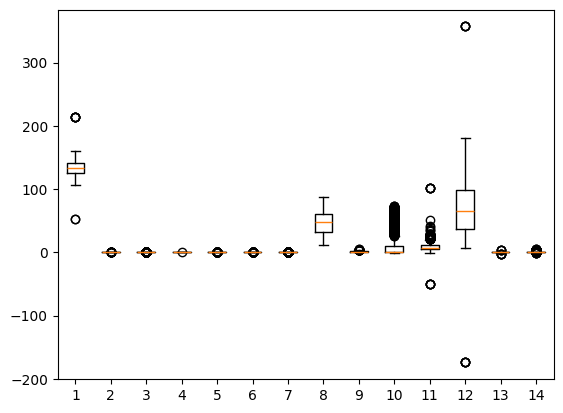

In [27]:
# Create a box plot to visualize the distribution and identify outliers in the data
# The dropna() method removes any NaN values before plotting
box=plt.boxplot(data.dropna())

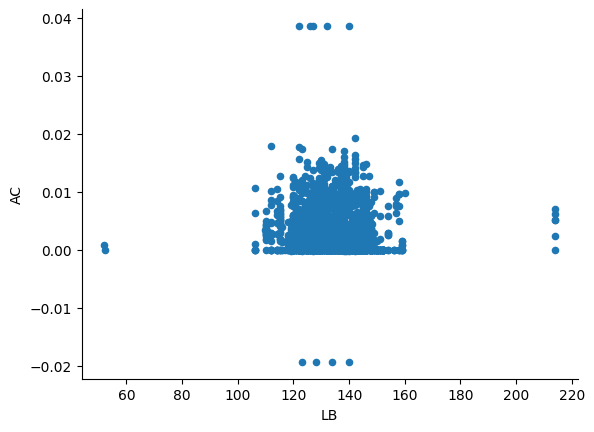

In [30]:
#Scatter Plots and Correlations

# Create a scatter plot of 'LB' vs 'AC' columns.
data.plot(kind='scatter', x='LB', y='AC')
# Remove the top and right borders of the plot for a cleaner look
plt.gca().spines[['top', 'right',]].set_visible(False)

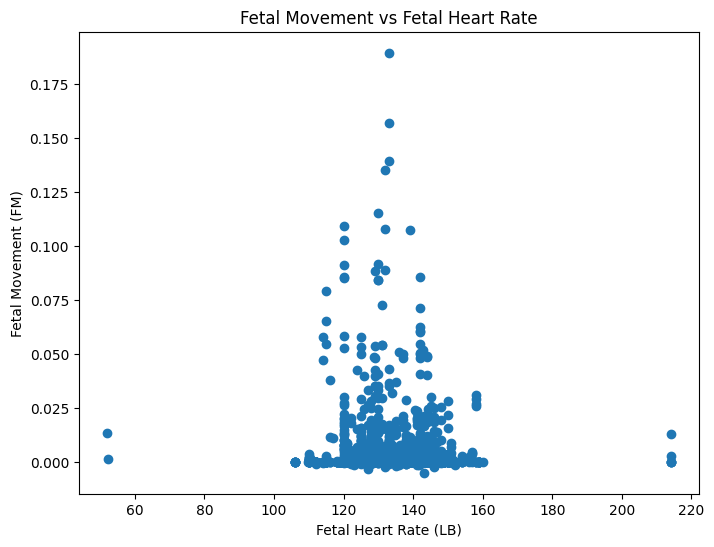

In [32]:
# Create a figure with specified dimensions (8 inches width, 6 inches height)
plt.figure(figsize=(8, 6))

# Create scatter plot of Fetal Movement vs Fetal Heart Rate
plt.scatter(data['LB'], data['FM'])

# Set x-axis label
plt.xlabel('Fetal Heart Rate (LB)')

# Set y-axis label
plt.ylabel('Fetal Movement (FM)')

# Set plot title and assign to _ since we don't need the return value
_ = plt.title('Fetal Movement vs Fetal Heart Rate')

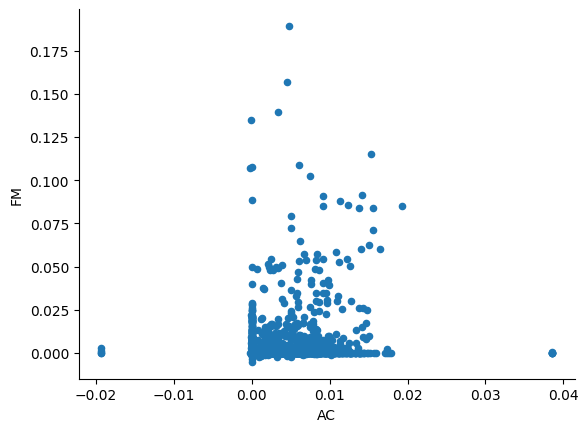

In [33]:
# Create a scatter plot comparing AC (x-axis) vs FM (y-axis)
data.plot(kind='scatter', x='AC', y='FM')
# Remove the top and right borders of the plot for a cleaner visualization
plt.gca().spines[['top', 'right',]].set_visible(False)

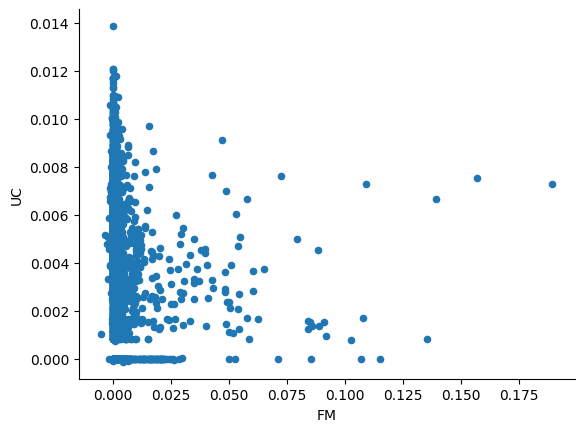

In [34]:
# Create a scatter plot comparing FM (x-axis) vs UC (y-axis)
data.plot(kind='scatter', x='FM', y='UC')
# Remove the top and right borders of the plot for a cleaner visualization
plt.gca().spines[['top', 'right',]].set_visible(False)

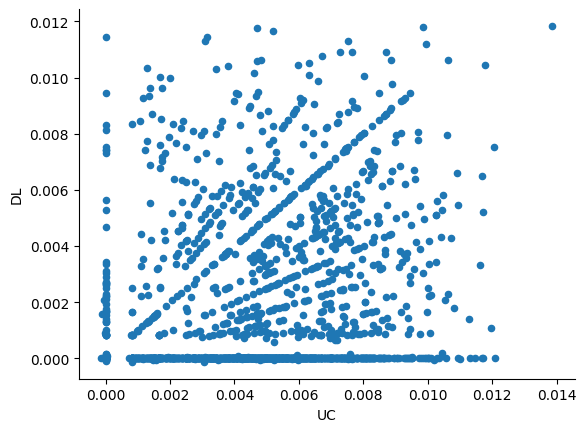

In [35]:
# Create a scatter plot of UC vs DL
data.plot(kind='scatter', x='UC', y='DL')
# Remove the top and right borders of the plot for a cleaner look
plt.gca().spines[['top', 'right',]].set_visible(False)

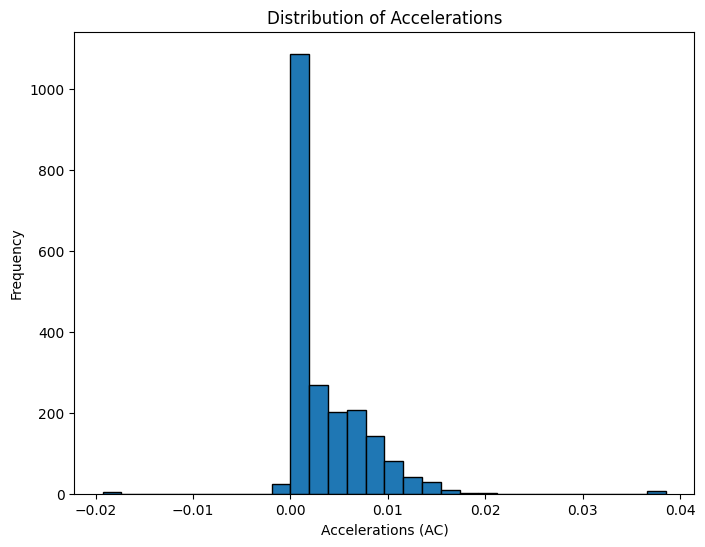

In [40]:
# Import matplotlib library for plotting
import matplotlib.pyplot as plt

# Create a figure with specified size (8 inches width, 6 inches height)
plt.figure(figsize=(8, 6))

# Create histogram of 'AC' column from data DataFrame
# Using 30 bins and black edges for better visibility
plt.hist(data['AC'], bins=30, edgecolor='black')

# Set x-axis label
plt.xlabel('Accelerations (AC)')

# Set y-axis label
plt.ylabel('Frequency')

# Set plot title and assign to _ since we don't need the return value
_ = plt.title('Distribution of Accelerations')

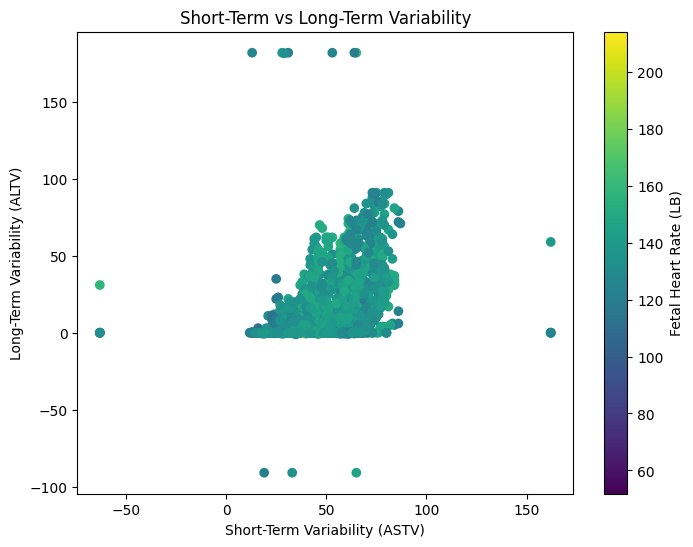

In [41]:
# Create a figure with specified dimensions (8x6 inches)
plt.figure(figsize=(8, 6))

# Create scatter plot comparing ASTV vs ALTV, colored by LB values
plt.scatter(data['ASTV'], data['ALTV'], c=data['LB'], cmap='viridis')

# Label x-axis
plt.xlabel('Short-Term Variability (ASTV)')

# Label y-axis
plt.ylabel('Long-Term Variability (ALTV)')

# Add title to plot
plt.title('Short-Term vs Long-Term Variability')

# Add color bar showing LB value scale
# Underscore captures the returned colorbar object which we don't need to use
_ = plt.colorbar(label='Fetal Heart Rate (LB)')

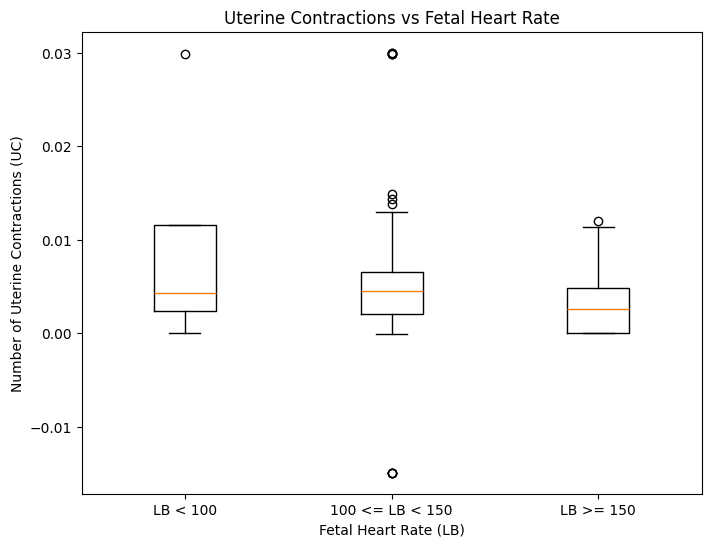

In [42]:
# Create a figure with specified size (8 inches width, 6 inches height)
plt.figure(figsize=(8, 6))

# Create boxplot showing UC distribution for different LB ranges
# First box: LB < 100
# Second box: 100 <= LB < 150
# Third box: LB >= 150
plt.boxplot([data['UC'][data['LB'] < 100],
            data['UC'][(data['LB'] >= 100) & (data['LB'] < 150)],
            data['UC'][data['LB'] >= 150]],
            labels=['LB < 100', '100 <= LB < 150', 'LB >= 150'])

# Add x-axis label
plt.xlabel('Fetal Heart Rate (LB)')

# Add y-axis label
plt.ylabel('Number of Uterine Contractions (UC)')

# Add title to the plot (underscore used to suppress output)
_ = plt.title('Uterine Contractions vs Fetal Heart Rate')

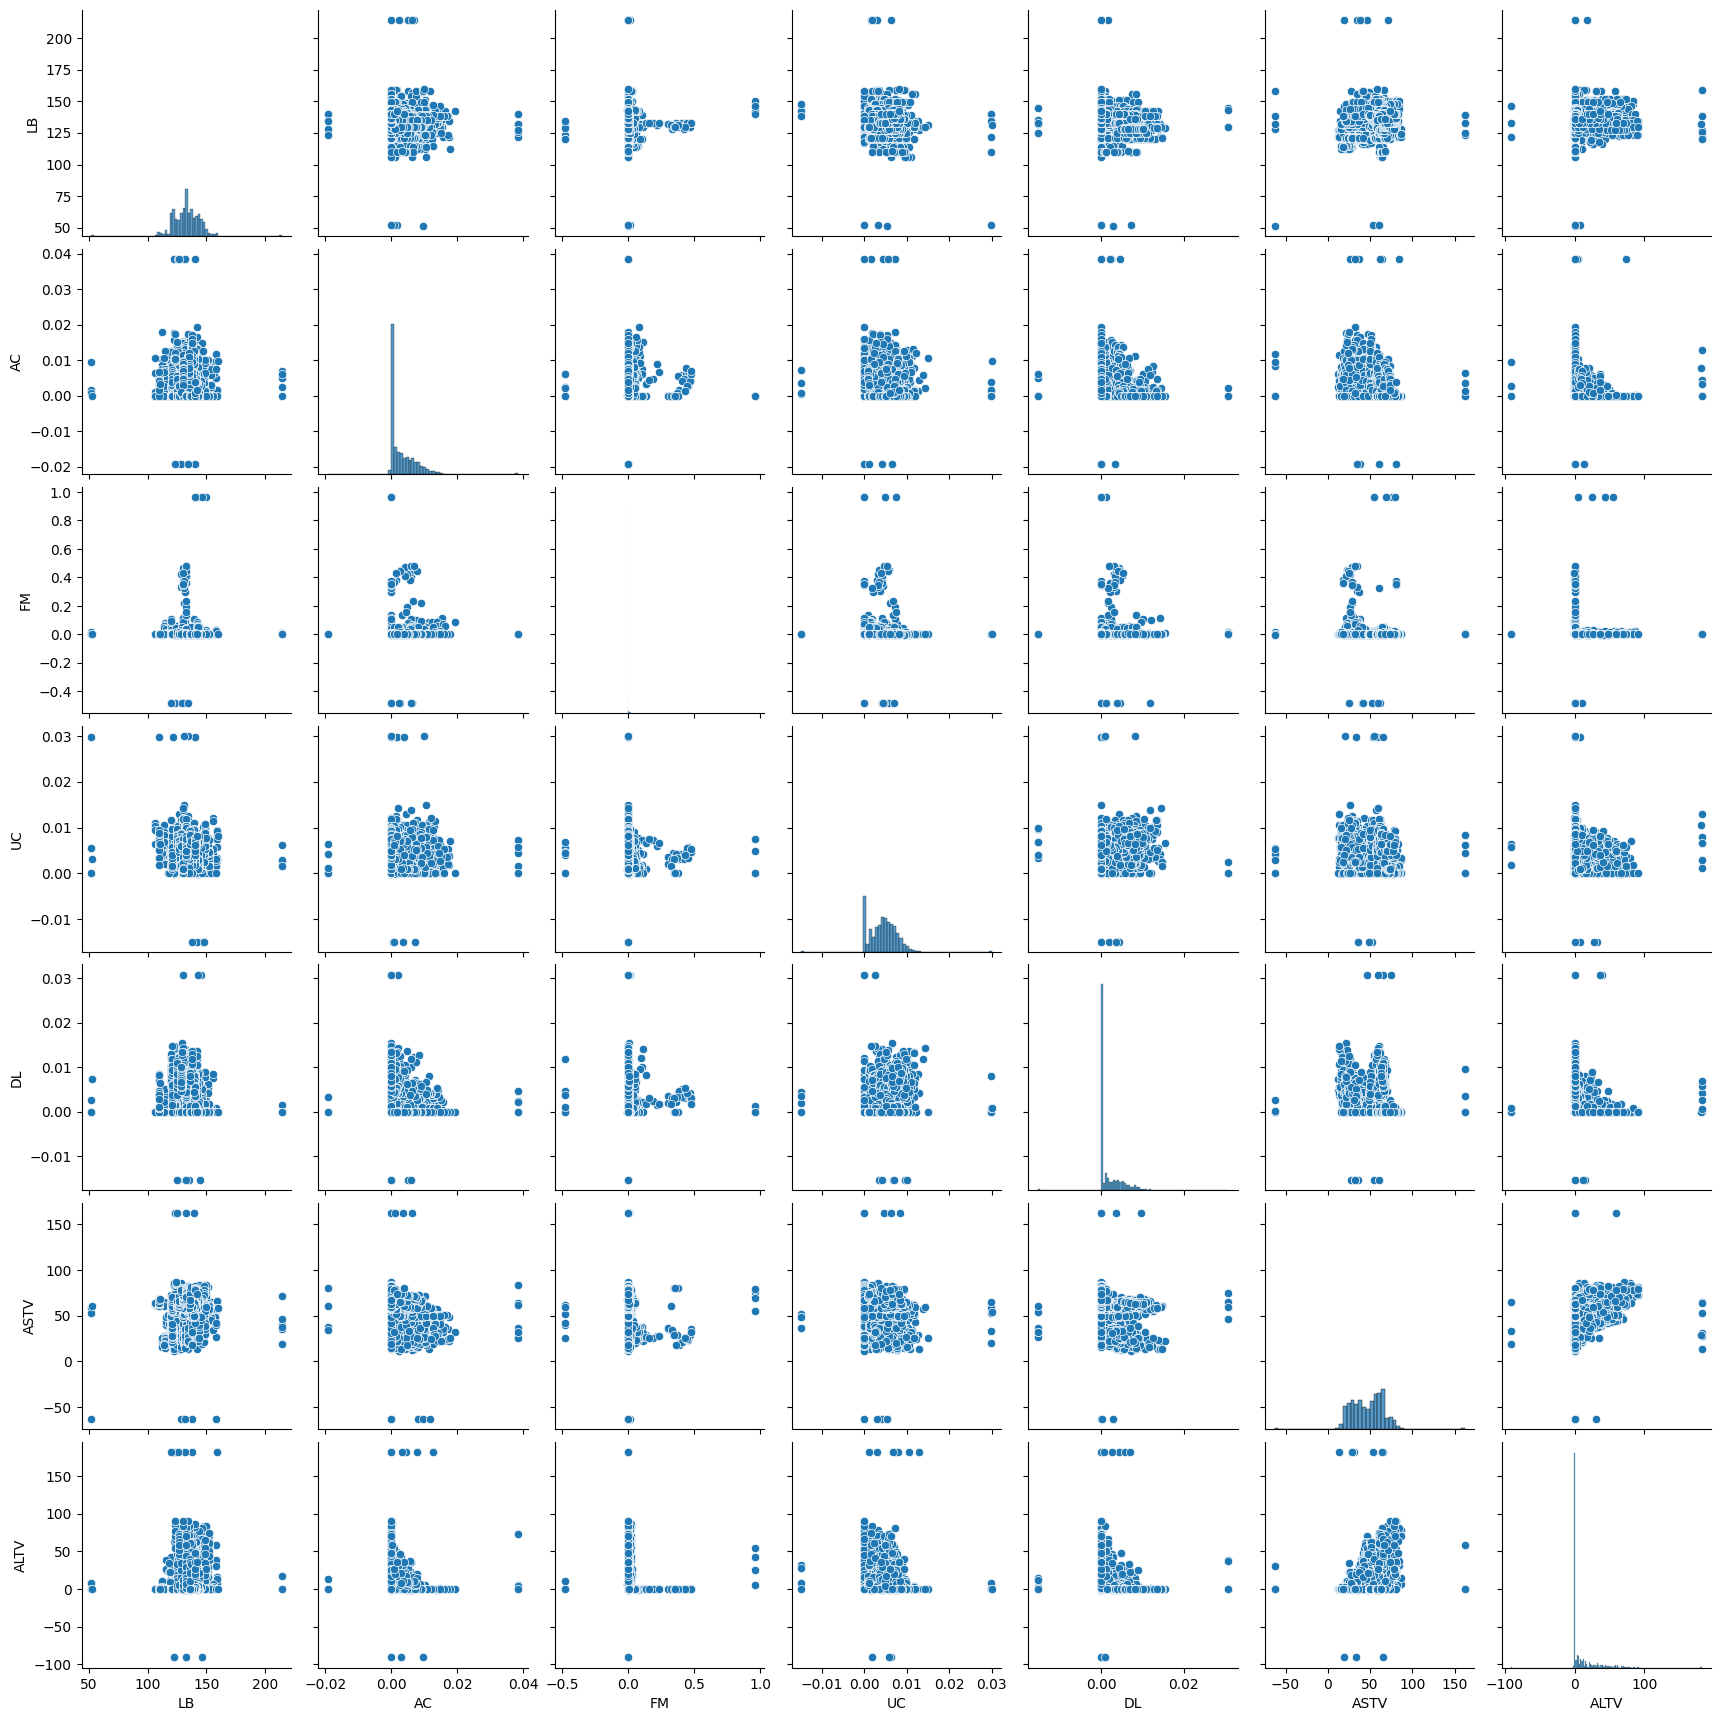

In [45]:
#Pair Plot

import seaborn as sns
import matplotlib.pyplot as plt

# Selecting relevant numerical columns for pair plot
numerical_cols = ['LB', 'AC', 'FM', 'UC', 'DL', 'ASTV', 'ALTV']
pair_plot_data = data[numerical_cols]


# Creating the pair plot
sns.pairplot(pair_plot_data)
plt.show()

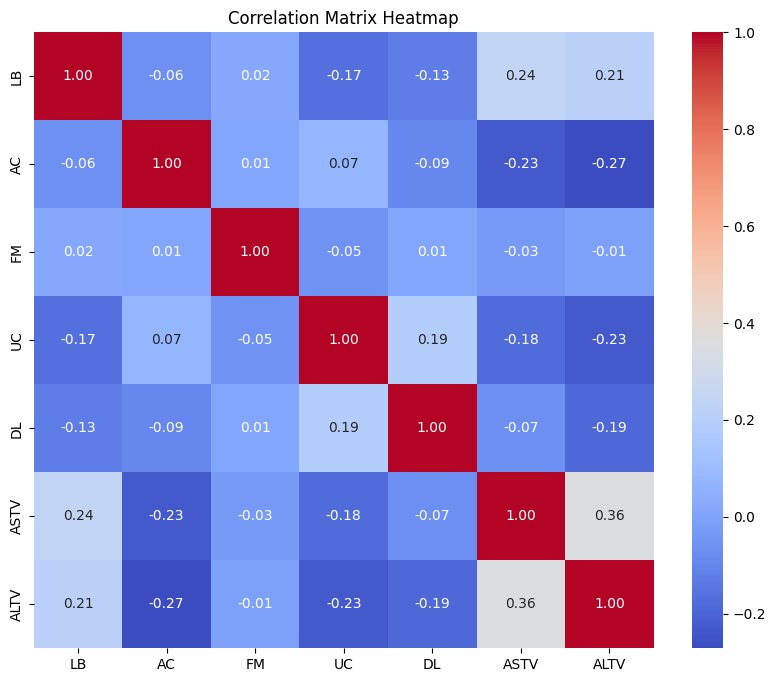

In [46]:
#Heatmap

# Select relevant numerical columns for the heatmap
numerical_cols = ['LB', 'AC', 'FM', 'UC', 'DL', 'ASTV', 'ALTV']
heatmap_data = data[numerical_cols]

# Calculate the correlation matrix
correlation_matrix = heatmap_data.corr()

# Create the heatmap
plt.figure(figsize=(10, 8))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

In [47]:
data.corr()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
LB,1.000000,-0.063830,0.018777,-0.166570,-0.126959,-0.005438,-0.047724,0.242625,-0.170473,0.210728,-0.003457,-0.118425,0.236864,0.131843
AC,-0.063830,1.000000,0.009433,0.072012,-0.093507,-0.033623,-0.084590,-0.231103,0.134168,-0.271390,-0.106529,0.238436,0.032481,-0.316941
FM,0.018777,0.009433,1.000000,-0.053226,0.009718,0.029901,0.121284,-0.032691,0.017055,-0.011936,-0.006237,0.097213,-0.018339,0.074054
UC,-0.166570,0.072012,-0.053226,1.000000,0.190128,-0.006937,0.070658,-0.181161,0.189406,-0.227304,-0.049460,0.107397,-0.066610,-0.185411
DL,-0.126959,-0.093507,0.009718,0.190128,1.000000,0.058625,0.145425,-0.069361,0.410102,-0.186967,-0.165750,0.410031,-0.023569,0.025427
DS,-0.005438,-0.033623,0.029901,-0.006937,0.058625,1.000000,0.004285,0.008452,0.016163,-0.004398,0.034349,0.040832,-0.015398,0.065400
DP,-0.047724,-0.084590,0.121284,0.070658,0.145425,0.004285,1.000000,0.038238,0.119892,-0.077758,-0.114084,0.175340,-0.130395,0.294472
ASTV,0.242625,-0.231103,-0.032691,-0.181161,-0.069361,0.008452,0.038238,1.000000,-0.293882,0.357497,-0.220427,-0.207599,-0.010927,0.422652
MSTV,-0.170473,0.134168,0.017055,0.189406,0.410102,0.016163,0.119892,-0.293882,1.000000,-0.291935,0.028934,0.435393,-0.036857,-0.095139
ALTV,0.210728,-0.271390,-0.011936,-0.227304,-0.186967,-0.004398,-0.077758,0.357497,-0.291935,1.000000,-0.107712,-0.346460,0.036771,0.365846


In [ ]:
#4. Pattern Recognition and Insights

# Fetal Heart Rate (FHR): FHR is mostly within the normal range (120–150 BPM) and symmetrically distributed, suggesting a stable baseline for fetal health assessment.

# Accelerations (AC), Movements (FM), and Contractions (UC): These events are rare and show highly skewed distributions, indicating that significant deviations may signal abnormal conditions.

# Decelerations (DL, DS, DP): Late, severe, and prolonged decelerations are infrequent, yet the occurrence of prolonged decelerations correlates moderately with variability metrics like MSTV, reflecting potential fetal distress when present.

# Short- and Long-Term Variability (ASTV, MSTV, ALTV, MLTV): The average variability measures are crucial indicators. MSTV and MLTV demonstrate high skewness, indicating their irregular occurrence. MSTV is responsible for the shape of the histogram generated in the cardiogram.

In [ ]:
# 5. Conclusion

# The exploratory data analysis reveals several key insights about the cardiotocographic data:

# The dataset contained outliers, which were removed using z-score analysis.  This cleaning step is crucial for reliable analysis.
# Many variables, such as Accelerations (AC), Fetal Movements (FM), and Uterine Contractions (UC), exhibit highly skewed distributions.
# This suggests that extreme values in these variables might be indicative of unusual or potentially problematic fetal conditions.
# Fetal Heart Rate (FHR) appears to be more normally distributed, centering around the typical range.
# The correlation matrix (and pair plot) highlights relationships between variables. Notably, correlations between short-term and long-term variability measures (ASTV, ALTV) and other parameters were observed.


# Impact on Decision-Making and Further Analyses:

# The identification and removal of outliers improves the reliability of subsequent analyses and modeling.  Future analyses might explore the characteristics of these removed outliers to understand potential edge cases.
# The skewed distributions of some variables suggest that transformations (e.g., logarithmic or Box-Cox transformations) might be beneficial for modeling.
# The results of further analyses and modeling should be rigorously validated against clinical outcomes to ensure their practical significance.
